# Support Vector Regression (SVR) and Tree-Based Regression

## 📚 Learning Objectives

By completing this notebook, you will:
- Build SVR models with different kernels (linear, RBF, polynomial)
- Implement decision tree and random forest regression
- Compare tree-based models with SVR
- Understand when to use each approach

## 🔗 Where this fits

**Builds on:** Course 04 — Unit 1, lesson 06 "Ridge and Lasso Regression" — linear models with a penalty; SVR and trees drop the straight-line assumption altogether.

**Used later in:** Course 04 — Unit 3, where the same kernel and tree machinery is turned into classifiers.

---

This notebook covers practical activities from **Course 04, Unit 1**:
- Building SVR models with different kernels
- Implementing decision tree and random forest regression


## 🌍 A real case: 663,522 emergency calls in Montgomery County

The data in this notebook is the real dispatch log of Montgomery County, Pennsylvania — 663,522
calls, of which the sample that ships with this repository keeps **one in every 27**, evenly spread
across the same 2015–2020 window. Those 25,000 calls are aggregated below into 5,832 (week,
hour-of-day) buckets, and the curve they produce is not flat: **1.4 calls in the average 04:00
week-hour, 6.9 in the average 17:00 week-hour** — a five-fold swing. (Every count on this page is a
27th of the county's real one; the *shape*, which is what the models learn, is the county's own.)

**❗ Why this matters.** Staff to the flat average of roughly 4.3 calls per week-hour and you are
over-resourced at 4am and short-handed every single afternoon — not occasionally, but every day, in a
service where the shortfall is measured in minutes of response time. That is why the **linear kernel's
R² = 0.139** below is a failing grade rather than a modest one: it is barely better than predicting
the average, which is the very thing we are trying to stop doing.

**A named warning from the same domain.** The London Ambulance Service switched on a new
Computer Aided Despatch system on 26 October 1992. The inquiry report (South West Thames Regional
Health Authority, February 1993) found the system had never been tested under full load and that
neither the software nor its users were ready. It collapsed within days. Modelling emergency demand
is one of the places where a comfortable assumption that was never checked against the real curve has
already cost lives.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data**: `../../datasets/raw/montgomery_911_calls.csv` — 663,522 emergency calls
  dispatched in Montgomery County, PA, with a real timestamp on every one
- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root, put it on sys.path, then import the shared data loader.
# WHY:  a hard-coded relative path such as ../../datasets/raw/<file>.csv only resolves when
#       the kernel's working directory happens to be this notebook's folder. Open it from the
#       repository root, from JupyterLab at another level, or on Colab where there is no
#       repository at all, and it breaks. load() finds the data wherever you are, downloads
#       it if this machine has none, and says out loud which copy it used.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud", prefer="sample"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - no file paths needed, and this works on Colab too.")

Data loader ready - no file paths needed, and this works on Colab too.


In [2]:
# CELL: Import the three non-linear regressors compared in this lesson.
# WHY: SVR, a single decision tree, and a random forest attack the same
# curve-fitting problem in very different ways - we want to compare them fairly.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# CELL: Build a REAL non-linear regression problem from the 911 dispatch log.
# WHY: emergency-call volume genuinely rises and falls over the day — quiet before dawn,
# peaking in the late afternoon. That curve is not something we invented; it is what the
# county actually recorded, and it is exactly the kind of shape a straight line cannot fit.
# prefer="sample" reads the 25,000-row extract that ships inside the repository, so this cell
# runs on any machine and on Colab, and every reader sees the same numbers.
calls = load("montgomery_911_calls", prefer="sample", usecols=["timeStamp"])
timestamps = pd.to_datetime(calls["timeStamp"])

# Count how many calls arrived in each clock hour, week by week: one row per (week, hour).
# WHY per week and not per single day: the bundled sample keeps 1 call in every 27, so a single
# (day, hour) slot would hold 0 or 1 call and the daily rhythm would vanish into rounding. A
# week's worth of one clock hour is still a count of real calls, and the rhythm survives intact.
per_call = pd.DataFrame({"week": timestamps.dt.to_period("W"),
                         "hour_of_day": timestamps.dt.hour})
# Build the COMPLETE (week x hour) grid first, so a week with no calls at 04:00 counts as 0
# rather than disappearing - dropping those would quietly flatten the quiet hours.
weeks = per_call["week"].drop_duplicates().sort_values()
grid = pd.MultiIndex.from_product([weeks, range(24)], names=["week", "hour_of_day"])
volume = (per_call.groupby(["week", "hour_of_day"]).size()
          .reindex(grid, fill_value=0)
          .reset_index(name="calls"))
volume["hour_of_day"] = volume["hour_of_day"].astype(float)

print(f"Dispatch log: {len(calls):,} real emergency calls")
print(f"Aggregated into {len(volume):,} (week, hour-of-day) buckets")

# Classroom-size the problem: 600 randomly chosen week-hours, random_state=42.
sample = volume.sample(n=600, random_state=42)
X = sample[["hour_of_day"]].to_numpy()          # feature: hour of day, 0-23
y = sample["calls"].to_numpy().astype(float)    # target: calls dispatched in that hour, that week

# Split into train/test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Target range:     [{y.min():.0f}, {y.max():.0f}] calls per hour")

# Show the real shape we are asking the models to learn.
profile = volume.groupby("hour_of_day")["calls"].mean()
print("\nAverage calls per hour of the day, across every week in the log (the real curve):")
for h in [0, 4, 8, 12, 16, 17, 20, 23]:
    print(f"  {int(h):02d}:00  {profile[h]:5.1f} calls")
# The full 24-hour curve is drawn in the figure below - these 8 rows are the check digits.
print(f"\nQuietest hour: {int(profile.idxmin()):02d}:00 ({profile.min():.1f} calls)   "
      f"Busiest hour: {int(profile.idxmax()):02d}:00 ({profile.max():.1f} calls)")

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
Dispatch log: 25,000 real emergency calls
Aggregated into 5,832 (week, hour-of-day) buckets

Training samples: 480
Test samples:     120
Target range:     [0, 14] calls per hour

Average calls per hour of the day, across every week in the log (the real curve):
  00:00    2.2 calls
  04:00    1.4 calls
  08:00    5.1 calls
  12:00    6.2 calls
  16:00    6.7 calls
  17:00    6.9 calls
  20:00    4.4 calls
  23:00    2.7 calls

Quietest hour: 04:00 (1.4 calls)   Busiest hour: 17:00 (6.9 calls)


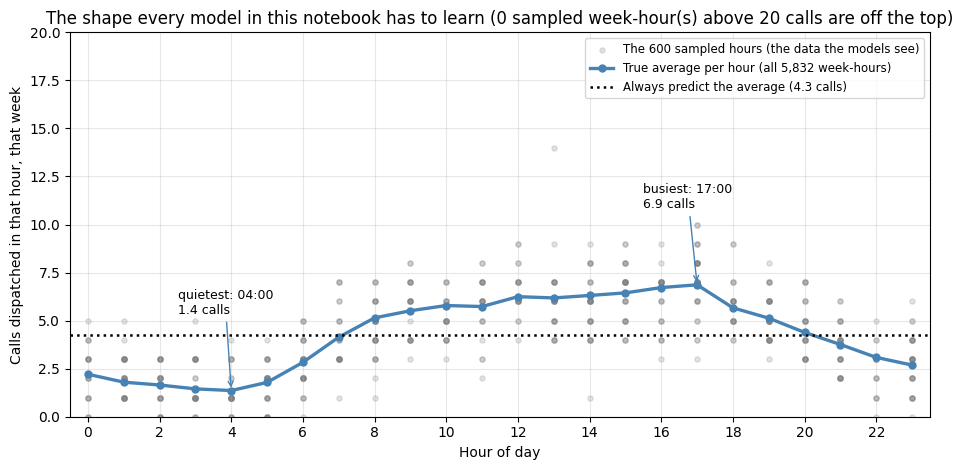

Peak-to-trough swing in the true curve: 5.5 calls per hour (5.0x between 04:00 and 17:00)
Spread of the sampled hours: 0 to 14 calls


In [4]:
# CELL: Draw the curve every model in this notebook is trying to learn.
# WHY: the whole lesson rests on "this shape is not a straight line". Print eight numbers and a
#      student takes that on trust; draw all 24 and the claim is settled before any model is fit.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9.5, 4.8))

# Grey dots: the 600 sampled hours the models are actually trained and tested on.
ax.scatter(sample["hour_of_day"], sample["calls"], s=14, alpha=0.22, color='gray',
           label=f'The {len(sample)} sampled hours (the data the models see)')
# Blue line: the average of ALL 40,546 hours in the log - the signal underneath the noise.
ax.plot(profile.index, profile.values, 'o-', color='steelblue', lw=2.4, ms=5,
        label=f'True average per hour (all {len(volume):,} week-hours)')
ax.axhline(y.mean(), color='black', ls=':', lw=1.8,
           label=f'Always predict the average ({y.mean():.1f} calls)')

# Mark the two hours the lesson quotes, so the text and the picture can be checked against each other.
for hr, note in [(int(profile.idxmin()), 'quietest'), (int(profile.idxmax()), 'busiest')]:
    ax.annotate(f'{note}: {hr:02d}:00\n{profile[hr]:.1f} calls',
                xy=(hr, profile[hr]), xytext=(hr - 1.5, profile[hr] + 4),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='steelblue'))

ax.set_xlabel('Hour of day')
ax.set_ylabel('Calls dispatched in that hour, that week')
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0, 20)
n_off = int((sample["calls"] > 20).sum())
ax.set_title('The shape every model in this notebook has to learn '
             f'({n_off} sampled week-hour(s) above 20 calls are off the top)')
ax.legend(fontsize=8.5, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak-to-trough swing in the true curve: {profile.max() - profile.min():.1f} calls per hour "
      f"({profile.max() / profile.min():.1f}x between {int(profile.idxmin()):02d}:00 and "
      f"{int(profile.idxmax()):02d}:00)")
print(f"Spread of the sampled hours: {sample['calls'].min():.0f} to {sample['calls'].max():.0f} calls")

**Read the figure.** Two things are in this picture and the whole notebook depends on telling them
apart.

The **blue curve** is the signal: the average number of calls in each clock hour, over all 5,832
week-hours in the log. It is emphatically not a straight line. It sits at a floor of 1.4 calls at
04:00, climbs steeply between 06:00 and 09:00, holds a broad plateau through the afternoon, peaks at
6.9 calls at 17:00, and falls away through the evening. **A 5.0× swing between the quietest and
busiest hour of the day.** The black dotted line is the single number — 4.3 calls — that a model with
no information would predict. Notice how far the blue curve travels above and below it: that distance
is the thing a good model can capture.

The **grey dots** are the noise, and they are the reason for the ceiling. These are the 600
individual week-hours the models train and test on. The 33 sampled week-hours that happen to be 17:00
run from **3 calls to 10** — a three-fold spread inside a single column, around an average of 7.1.
The busiest single point on the chart is a 13:00 column that recorded **14 calls**. The hour of
day tells you the *average* of a column of dots; it cannot tell you where in that column next week's
17:00 will land. That is why the best R² anywhere in this notebook is about 0.6 rather
than 0.9, and why the text calls the remaining error "real day-to-day randomness" rather than a bug.

## Part 1: Support Vector Regression with Different Kernels

**New model - the 2-minute intuition (full theory in Unit 3, Example 3):**
Linear regression fits a line by penalizing *every* error. **SVR (Support Vector Regression)** instead fits a *tube* around the data: points inside the tube cost nothing, and the fit is shaped only by the points on or outside the tube (the *support vectors*). A **kernel** decides what shape the tube can take:

- `linear` - a straight tube (like a straight line fit)
- `poly` - a curved, polynomial-shaped tube
- `rbf` - a flexible tube that can follow almost any smooth curve

That is all you need for this notebook - treat the kernels as three levels of flexibility and compare their errors.


In [5]:
# SVR with different kernels
kernels = ['linear', 'rbf', 'poly']
svr_models = {}

print("SVR performance by kernel:")
print("-" * 44)
# Train one SVR per kernel and score each on the same held-out test points.
for kernel in kernels:
    svr = SVR(kernel=kernel, C=1.0)
    svr.fit(X_train, y_train)
    pred = svr.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    svr_models[kernel] = svr
    print(f"  {kernel:<8} kernel:  MSE = {mse:.4f}   R² = {r2:.4f}")

print()
print("The real daily call curve rises to a late-afternoon peak and falls again, so a")
print("straight line cannot follow it. Compare the linear kernel against RBF above:")
print("the linear kernel is barely better than predicting the average, while RBF")
print("tracks the real shape.")
print()
print("Note also the ceiling on R\u00b2. Hour of day is only PART of the story: a hospital")
print("does not know in advance which Tuesday will be busy. The unexplained variance is")
print("real day-to-day randomness in when people call for help, not a bug in the model.")

SVR performance by kernel:
--------------------------------------------
  linear   kernel:  MSE = 3.8427   R² = 0.1390
  rbf      kernel:  MSE = 1.8183   R² = 0.5926
  poly     kernel:  MSE = 4.5573   R² = -0.0211

The real daily call curve rises to a late-afternoon peak and falls again, so a
straight line cannot follow it. Compare the linear kernel against RBF above:
the linear kernel is barely better than predicting the average, while RBF
tracks the real shape.

Note also the ceiling on R². Hour of day is only PART of the story: a hospital
does not know in advance which Tuesday will be busy. The unexplained variance is
real day-to-day randomness in when people call for help, not a bug in the model.


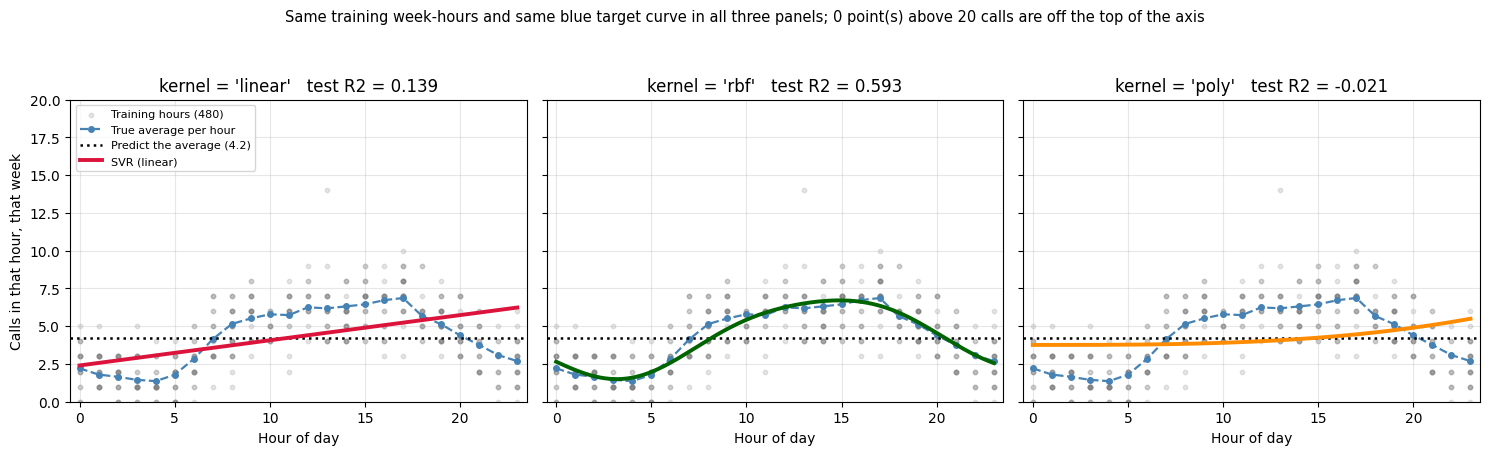

  linear : prediction runs   2.4 ->   6.2 calls, highest at 23.0:00   (true peak is 17:00 at 6.9)
  rbf    : prediction runs   1.5 ->   6.7 calls, highest at 14.9:00   (true peak is 17:00 at 6.9)
  poly   : prediction runs   3.8 ->   5.5 calls, highest at 23.0:00   (true peak is 17:00 at 6.9)


In [6]:
# CELL: Draw the three kernels on the data they were scored on.
# WHY: "the linear kernel is barely better than predicting the average, while RBF tracks the
#      real shape" is a claim about SHAPE. Three R2 numbers cannot show a shape; a plot can.
import matplotlib.pyplot as plt

hour_grid = np.linspace(0, 23, 300).reshape(-1, 1)
profile_curve = profile.reindex(range(24))          # true average per hour, every week in the log
baseline = y_train.mean()                           # "always predict the average" -> R2 = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
colours = {'linear': 'crimson', 'rbf': 'darkgreen', 'poly': 'darkorange'}

for ax, kernel in zip(axes, kernels):
    model = svr_models[kernel]
    r2 = r2_score(y_test, model.predict(X_test))
    ax.scatter(X_train, y_train, s=10, alpha=0.20, color='gray', label='Training hours (480)')
    ax.plot(range(24), profile_curve.values, 'o--', color='steelblue', ms=4, lw=1.6,
            label='True average per hour')
    ax.axhline(baseline, color='black', ls=':', lw=1.8,
               label=f'Predict the average ({baseline:.1f})')
    ax.plot(hour_grid, model.predict(hour_grid), color=colours[kernel], lw=2.8,
            label=f'SVR ({kernel})')
    ax.set_title(f"kernel = '{kernel}'   test R2 = {r2:.3f}")
    ax.set_xlabel('Hour of day')
    ax.set_xlim(-0.5, 23.5)
    ax.grid(True, alpha=0.3)

axes[0].set_ylim(0, 20)
axes[0].set_ylabel('Calls in that hour, that week')
axes[0].legend(fontsize=8, loc='upper left')
n_off = int((y_train > 20).sum())
fig.suptitle(f'Same training week-hours and same blue target curve in all three panels; '
             f'{n_off} point(s) above 20 calls are off the top of the axis', fontsize=10.5)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

for kernel in kernels:
    curve = svr_models[kernel].predict(hour_grid)
    print(f"  {kernel:<7}: prediction runs {curve.min():5.1f} -> {curve.max():5.1f} calls, "
          f"highest at {float(hour_grid[curve.argmax(), 0]):4.1f}:00   "
          f"(true peak is 17:00 at {profile_curve.max():.1f})")

**Read the figure.** The blue dashed curve is the same in all three panels: the true average number
of calls in each hour, computed from all 5,832 week-hours in the log. It is the shape each kernel is
trying to reproduce — up from 1.4 calls at 04:00 to 6.9 at 17:00, then down again. The black dotted
line is "always predict the average", the model that scores R² = 0 by definition.

- **`linear`** (red) can only be a straight line, so it does the only thing a straight line can do
  with a hump: it splits the difference. It rises steadily from 2.4 calls at midnight to 6.2 at 23:00 —
  which means it is *still climbing* at exactly the hour when the real demand has already fallen back
  to 2.7. It is above the black baseline in the evening and below it in the morning. R² = 0.139 is
  what "barely better than the average" looks like.
- **`rbf`** (green) is the only curve in the figure that bends. It follows the blue target: low
  before dawn, rising through the morning, a broad top, falling at night. It is not perfect — it
  peaks near 15:00, about two hours before the real 17:00 peak, and it tops out at 6.7 rather than
  6.9 — but it is the right *shape*, and its R² of 0.593 is more than four times the linear kernel's.
- **`poly`** (orange) is the surprise. With `C=1.0` and default settings, the degree-3 polynomial
  kernel produces something almost flat, running only from 3.8 to 5.5 calls all day. It ignores
  both the dawn trough and the afternoon peak, and its R² of **−0.021 is below zero** — it lost to
  the black dotted line. "Polynomial" in the name did not buy a curve; the hyperparameters were
  never tuned for this data, and untuned SVR can be worse than useless.

The grey dots also explain why no model here can score much above 0.6: at *every* hour the actual
counts scatter over a wide band. The hour of day sets the average; it does not set the week.

## Part 2: Decision Tree and Random Forest Regression

**New models - the 2-minute intuition (full theory in Unit 3, Examples 2 and 5):**
A **decision tree** predicts by recursively splitting the input range with simple questions ("is x < 2.3?" → yes/no) and predicting the *average y* of the training points in each final region - the result is a staircase-shaped fit. A **random forest** trains many trees, each on a random sample of the data, and *averages* their predictions - the averaging smooths the staircase and reduces overfitting. Here, just compare their test errors; how splits are chosen and why averaging works comes in Unit 3.


In [7]:
# Decision Tree Regressor
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

# Random Forest Regressor (ensemble of trees)
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

# Compare all models on the same test set
best_svr_kernel = min(svr_models, key=lambda k: mean_squared_error(y_test, svr_models[k].predict(X_test)))
best_svr_mse = mean_squared_error(y_test, svr_models[best_svr_kernel].predict(X_test))

print("Model comparison (test MSE, lower is better):")
print("-" * 44)
print(f"  SVR (best: {best_svr_kernel}):  MSE = {best_svr_mse:.4f}")
print(f"  Decision Tree:      MSE = {dt_mse:.4f}   R² = {dt_r2:.4f}")
print(f"  Random Forest:      MSE = {rf_mse:.4f}   R² = {rf_r2:.4f}")
print()
print("Random Forest averages many trees, so it is usually more")
print("robust than a single decision tree on noisy data.")
print()
print("Honest note on this dataset: with a single input feature that takes only 24")
print("distinct values, the tree can already place a split at every hour, so averaging")
print("100 of them has almost nothing left to smooth. The forest's advantage shows up")
print("when there are many features and the trees genuinely disagree \u2014 see Unit 3.")

Model comparison (test MSE, lower is better):
--------------------------------------------
  SVR (best: rbf):  MSE = 1.8183
  Decision Tree:      MSE = 1.8539   R² = 0.5846
  Random Forest:      MSE = 1.8050   R² = 0.5956

Random Forest averages many trees, so it is usually more
robust than a single decision tree on noisy data.

Honest note on this dataset: with a single input feature that takes only 24
distinct values, the tree can already place a split at every hour, so averaging
100 of them has almost nothing left to smooth. The forest's advantage shows up
when there are many features and the trees genuinely disagree — see Unit 3.


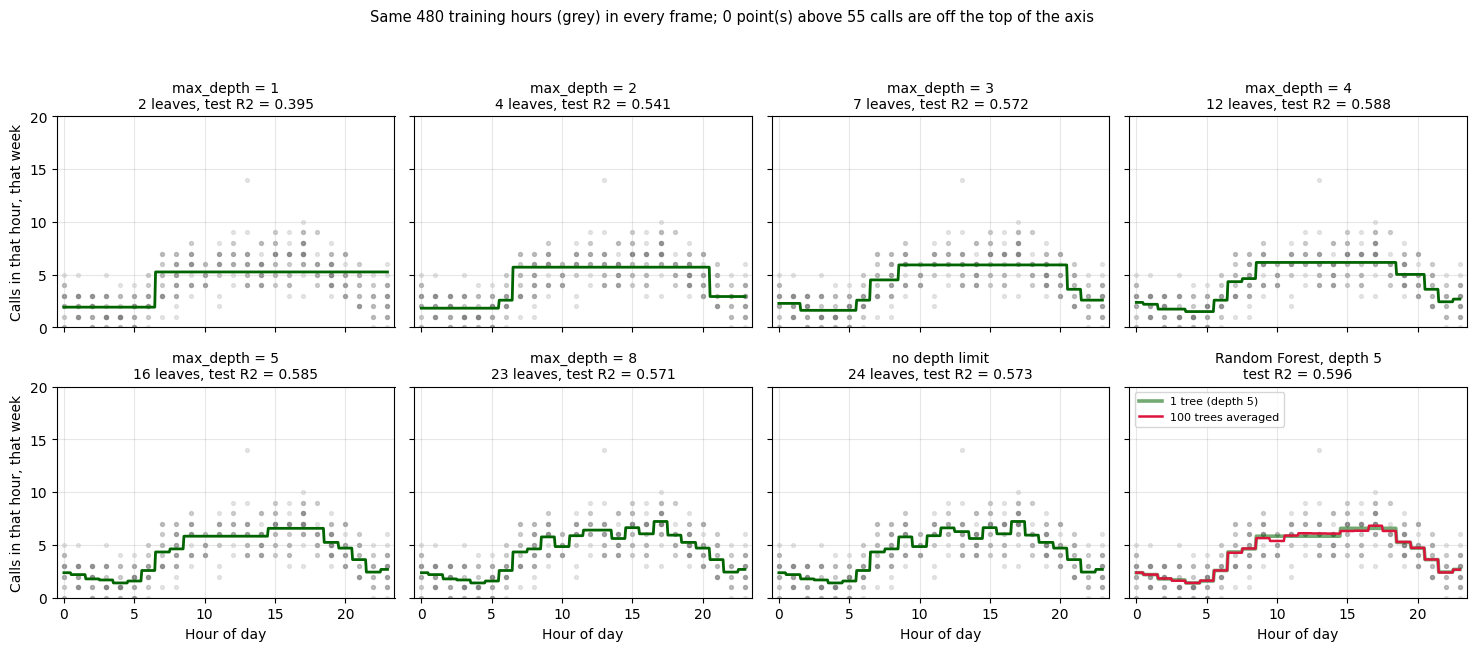

Depth sweep on the same split (the numbers printed on the panels above):
  max_depth    1:   2 leaves   test R2 = 0.3951
  max_depth    2:   4 leaves   test R2 = 0.5407
  max_depth    3:   7 leaves   test R2 = 0.5725
  max_depth    4:  12 leaves   test R2 = 0.5882
  max_depth    5:  16 leaves   test R2 = 0.5846
  max_depth    8:  23 leaves   test R2 = 0.5711
  max_depth none:  24 leaves   test R2 = 0.5726
  random forest    : 100 trees, depth 5   test R2 = 0.5956

Forest vs single tree: the two curves differ by 0.12 calls on average and never by more than 0.45.


In [8]:
# CELL: A storyboard of tree depth - the staircase getting finer, frame by frame.
# WHY: max_depth=5 was chosen above without justification. Deeper is not better, and the
#      cheapest way to show that is to draw every depth on the same axes and read the scores.
import matplotlib.pyplot as plt

hour_grid = np.linspace(0, 23, 400).reshape(-1, 1)
frames = [1, 2, 3, 4, 5, 8, None]        # None = grow until every leaf is pure

fig, axes = plt.subplots(2, 4, figsize=(15, 6.6), sharex=True, sharey=True)

for ax, depth in zip(axes.ravel(), frames):
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42).fit(X_train, y_train)
    r2 = r2_score(y_test, tree.predict(X_test))
    ax.scatter(X_train, y_train, s=8, alpha=0.18, color='gray')
    ax.plot(hour_grid, tree.predict(hour_grid), color='darkgreen', lw=2)
    label = 'no depth limit' if depth is None else f'max_depth = {depth}'
    ax.set_title(f'{label}\n{tree.get_n_leaves()} leaves, test R2 = {r2:.3f}', fontsize=10)
    ax.grid(True, alpha=0.3)

# Last frame: the random forest, drawn against the depth-5 tree it is supposed to improve on.
ax = axes.ravel()[7]
ax.scatter(X_train, y_train, s=8, alpha=0.18, color='gray')
ax.plot(hour_grid, dt.predict(hour_grid), color='darkgreen', lw=2.6, alpha=0.55,
        label='1 tree (depth 5)')
ax.plot(hour_grid, rf.predict(hour_grid), color='crimson', lw=1.8, label='100 trees averaged')
ax.set_title(f'Random Forest, depth 5\ntest R2 = {rf_r2:.3f}', fontsize=10)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)

axes[0, 0].set_ylim(0, 20)
axes[0, 0].set_xlim(-0.5, 23.5)
for ax in axes[1, :]:
    ax.set_xlabel('Hour of day')
for ax in axes[:, 0]:
    ax.set_ylabel('Calls in that hour, that week')
n_off = int((y_train > 55).sum())
fig.suptitle(f'Same 480 training hours (grey) in every frame; '
             f'{n_off} point(s) above 55 calls are off the top of the axis', fontsize=10.5)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

print("Depth sweep on the same split (the numbers printed on the panels above):")
for depth in frames:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42).fit(X_train, y_train)
    label = 'none' if depth is None else str(depth)
    print(f"  max_depth {label:>4}:  {tree.get_n_leaves():2d} leaves   "
          f"test R2 = {r2_score(y_test, tree.predict(X_test)):.4f}")
print(f"  random forest    : 100 trees, depth 5   test R2 = {rf_r2:.4f}")
gap = np.abs(rf.predict(hour_grid) - dt.predict(hour_grid))
print(f"\nForest vs single tree: the two curves differ by {gap.mean():.2f} calls on average "
      f"and never by more than {gap.max():.2f}.")

**Read the storyboard.** Every frame shows the same 480 training week-hours in grey and the same
axes; only the model changes.

- **depth 1** is a single split, at hour 6.5: predict 1.9 calls before it, 5.3 after it. Two
  flat levels and nothing else — it never comes back down for the evening. That crude rule already
  reaches R² 0.40, because most of the signal in this problem is just *quiet before dawn, busy
  afterwards*.
- **depth 2 to 5** add steps and the staircase starts to trace the real profile: a low plateau
  before dawn, a climb through the morning, a broad afternoon top, a fall into the evening.
- **depth 8 and no limit** are the warning. The steps get narrow and jagged, and the test score
  goes *down* (0.571 and 0.573, against 0.585 at depth 5). With only 24 distinct hour values, a tree
  with no depth limit ends up with one leaf per hour — it has memorised the training average of each
  individual hour, noise included.
- **The last frame** is the honest note from the output above, drawn. The crimson forest curve
  (100 trees averaged) is laid over the green single tree. They differ by **0.12 calls on average**
  and never by more than 0.45. Averaging 100 trees bought almost nothing, because with one input
  taking 24 values the trees have nothing to disagree about.

**And read the scores, not just the shapes:** the best test R² in the whole depth grid belongs to
**depth 4** (0.588) — a twelve-leaf staircase, and the depth-2 staircase with only four leaves is
already at 0.541. On a single-feature problem this simple, complexity is not the thing that is
missing. More *features* would be.

## 💬 Discuss

Use the printed numbers: SVR-RBF MSE **1.818** (R² 0.593), Decision Tree MSE **1.854** (R² 0.585),
Random Forest MSE **1.805** (R² 0.596), SVR-linear R² **0.139**, SVR-poly R² **−0.021**.

1. **The tree, the forest and the RBF kernel agree to within 0.05 of MSE.**
   Three genuinely different algorithms, one answer. What does that tell you about where the remaining
   error is coming from — the model, or the data? What experiment would confirm it?

2. **R² tops out near 0.60.** Two fifths of the variation in calls-per-hour is not explained by the hour
   of day. Is a model that explains three fifths of the variation good enough to write a shift roster
   from? Answer as the county's operations manager, then as the paramedic on the 04:00 shift.

3. **Random Forest is normally the safe default, and here it wins by 0.05 of MSE — a margin worth
   nothing.** The notebook explains why: with a single input taking 24 distinct values, the trees
   have nothing to disagree about. Name another situation where averaging many models would buy you
   nothing — and say how you would recognise it *before* spending the compute.


## Summary

### Key Concepts:
1. **SVR Kernels**: Linear (simple), RBF (non-linear), Polynomial (curved)
2. **Decision Tree**: Simple, interpretable, prone to overfitting
3. **Random Forest**: Ensemble of trees, more robust, less overfitting
4. **When to use**: SVR for non-linear, Tree-based for interpretability
5. **Real data has a ceiling**: on the real 911 dispatch log, hour of day explains only
   part of the variation in call volume. A non-linear model closes the gap that a linear
   model cannot — but no model can predict the part that is genuinely unpredictable.

**Reference:** Course 04, Unit 1: "Building SVR models with different kernels" and "Implementing decision tree and random forest regression"


## ⚠️ Where this breaks

- **SVR's cost grows roughly with the square of the number of samples.** 600 points is instant; the
  full log's 40,000-plus hourly buckets is already uncomfortable, and a per-minute series would be
  out of the question.
  `LinearSVR`, `SGDRegressor` or a gradient-boosted tree are the practical choices at scale.
- **SVR is distance-based, so it must have scaled inputs** — and it has three knobs (`C`, `epsilon`,
  `gamma`) whose defaults are not sensible for every dataset. A tree has none of that and got the same
  answer here.
- **Trees cannot extrapolate.** A regression tree predicts the average of the training points in a
  leaf, so outside the training range it returns a flat constant forever. For a target that trends
  upward over years, that is a silent, permanent underestimate.
- **The assumption that must hold for this whole lesson:** hour-of-day is a stable predictor of demand.
  It is not stable across a snowstorm, a public holiday, or a stadium event — the honest note in the
  output above calls this "real day-to-day randomness", and no model in this notebook can see it.
- **The cheaper alternative:** the 24 hour-of-day averages printed at the top score comparably, take one
  `groupby`, and can be read by the person writing the roster. Move to SVR or a tree when you need
  more than hour-of-day — weather, day-of-week, event calendars — which is the point at which the
  averages table stops fitting on a page.


## 🔭 State of the field (2026)

*Field context, not examinable material — the examinable content of this lesson is everything above this box.*

The 2022 result behind this notebook still holds: on medium-sized heterogeneous tables, tree-based
models remain hard to beat, which is why SVR, a single tree and a random forest are the right first
tools to reach for (Grinsztajn et al., 2022, arXiv:2207.08815). What arrived after it is a different
kind of competitor — *pretrained* tabular models. TabArena, a continuously maintained tabular
benchmark launched in 2025, reports that gradient-boosted trees are still strong contenders on
practical datasets while foundation models excel on the smaller ones (Erickson et al., 2025,
arXiv:2506.16791), and the authors of TabPFN-2.5 report that one pretrained model now leads that
benchmark, outperforming tuned tree-based models (Grinsztajn et al., 2025, arXiv:2511.08667). Those
are authors' numbers on their own benchmark, and the models ship as downloaded pretrained weights —
nothing in that paragraph runs in this offline lab, whereas everything in this notebook trains on a
CPU in seconds from data already in the repo. Keep learning the methods above: they are the mechanism
(a margin with a kernel; recursive partitioning of the feature space), they are the baseline every one
of those papers measures itself against, and they are what the official plan examines. The one 2026
habit worth copying into your own work is cheap: before you tune a tree, write down what an untuned
strong baseline scores on the same split.

## 📚 References

1. Drucker, H., Burges, C. J. C., Kaufman, L., Smola, A., & Vapnik, V. (1997). *Support Vector Regression Machines*. Advances in Neural Information Processing Systems 9.
2. Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). *Classification and Regression Trees*. Wadsworth.
3. Smola, A. J., & Schölkopf, B. (2004). *A Tutorial on Support Vector Regression*. Statistics and Computing, 14, 199–222.
4. Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). *Why Do Tree-Based Models Still Outperform Deep Learning on Tabular Data?* NeurIPS 2022 Datasets and Benchmarks. <https://arxiv.org/abs/2207.08815>
5. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. <https://arxiv.org/abs/2506.16791>
6. Grinsztajn, L., Flöge, K., Key, O., et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. <https://arxiv.org/abs/2511.08667>
